### 📦 Importing Required Libraries

This cell imports all the necessary Python libraries for data analysis and plotting:

- `numpy`, `pandas` for data handling  
- `matplotlib.pyplot`, `seaborn` for plotting and visualization  
- `os`, `pathlib.Path` for file handling  
- `scipy` libraries for signal processing and curve fitting  
- `sklearn.metrics.r2_score` for computing the R² value  
- `%matplotlib inline` ensures that plots display directly in the notebook

In [61]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import scipy
from scipy.optimize import curve_fit
import scipy.signal
from scipy.io import loadmat
import re
from scipy.interpolate import interp1d
import scipy.signal as signal
from sklearn.metrics import r2_score


# Ensure plots are rendered in the notebook
%matplotlib inline

## Defining terms for the exponential function 

In [62]:
dict_for_plotting = {}
for name in ['0', '100', '200', '300', '400', '500']:
    dict_for_plotting[name] = []

In [63]:
# Define exponential functions
def old_exp_decrease(t, A, tau, C, t0):
    return A / (1 + np.exp((t-175-t0) / tau)) + C

def exp_decrease(t, tau, t0):
    global speed_initial
    global speed_final
    return (speed_initial-speed_final) / (1 + np.exp((t-175-t0) / tau)) + speed_final

def exp_increase(t, tau, t0):
    global speed_increase_max
    global speed_increase_min
    return speed_increase_min + (speed_increase_max  - speed_increase_min)/ (1 + np.exp(-(t-270-t0) / tau))

def old_exp_increase(t, B, tau, D, t0):
    return B * (1 - np.exp(-(t - t0) / tau)) + D

def exponential_decay(t, tau, t0):
    global speed_initial
    global speed_final
    return np.where(t < t0, speed_initial, (speed_initial-speed_final) * np.exp(-(t - t0) / tau) + speed_final)

def calculate_time_constants(time, speed, filename, sucrose_choice):
    results = []

    #normalize speed for ease of fitting
    speed = speed / np.average(speed[time<=180]) #normally 300

    # Filter data for decrease and increase
    mask_decrease = (time >= 175) & (time <= 240)
    time_decrease = time[mask_decrease]
    speed_decrease = speed[mask_decrease]

    mask_increase = (time > 250) & (time <= 360)
    time_increase = time[mask_increase]
    speed_increase = speed[mask_increase]
   
    global speed_initial
    global speed_final
    speed_initial = np.average(speed[(time >= 155) & (time <= 175)])
    speed_final = np.average(speed[(time >= 215) & (time <= 235)])

    global speed_increase_max
    global speed_increase_min
    speed_increase_min = np.average(speed[(time >= 240) & (time <= 260)])
    speed_increase_max = np.average(speed[(time >= 330) & (time <= 350)])


    global dict_for_plotting
    dict_for_plotting[filename].append(speed[(time >= 155) & (time <= 175)])
    dict_for_plotting['0'].append(speed[(time >= 215) & (time <= 235)])

    #Fit the decrease segment
    try:
        popt_decrease, _ = curve_fit(
            exp_decrease,
            time_decrease,
            speed_decrease,
            p0=[10, 10],
            bounds=(0, np.inf)
        )
        A_dec, C_dec = speed_initial-speed_final, speed_final
        tau_dec, t0_dec = popt_decrease
    except Exception as e:
        print(f"Error fitting decrease for {filename}: {e}")
        tau_dec = np.nan
        A_dec, tau_dec, C_dec, t0_dec = [np.nan, np.nan, np.nan, np.nan]
        popt_decrease = [np.nan, np.nan, np.nan, np.nan]

    if True: #plotting to double check
        if filename == "500": #filename[-13:-10]
            #print('here')
            plt.plot(time, speed)
            plt.plot(time_decrease, exp_decrease(time_decrease, *popt_decrease))


    # Fit the increase segment
    try:
        popt_increase, _ = curve_fit(
            exp_increase, time_increase, speed_increase, p0=[3, -10]
        )
        tau_inc, t0_inc = popt_increase
    except Exception as e:
        print(f"Error fitting increase for {filename}: {e}")
        tau_inc = np.nan
        popt_increase = [np.nan, np.nan]

    if True:
        if filename == "500":
            plt.plot(time_increase, exp_increase(time_increase, *popt_increase))

    # Save results for this concentration
    condition = filename.split(".csv")[
        0
    ]  # Assuming the filename contains the concentration info
    results.append(
        {
            "Condition": condition,
            "Tau (Decrease)": tau_dec,
            "Tau (Increase)": tau_inc,
            "Time Range (Decrease)": f"180-270",
            "Time Range (Increase)": f"270-{time[-1]}",
        }
    )

    return tau_dec, t0_dec, A_dec, tau_inc

### Data Processing Functions

This section defines three functions used to process time-series data by interpolating to a fixed frame rate and binning into defined intervals:



In [64]:
def convert_to_300fps(time_stamps, data, target_fps=300):# Calculate the total duration
    total_time = time_stamps[-1]
    
    # Generate new time stamps at the target FPS
    new_time_stamps = np.linspace(0, total_time, int(total_time * target_fps))
    
    # Create a linear interpolator
    interpolator = interp1d(time_stamps, data, kind='linear', fill_value='extrapolate')
    
    # Interpolate data to the new time stamps
    interpolated_data = interpolator(new_time_stamps)
    
    return new_time_stamps[:380*target_fps], interpolated_data[:380*target_fps]

def bin_data(time_stamps, data, bin_size=0.1):
    data = data[time_stamps < 380]
    time_stamps = time_stamps[time_stamps < 380]
    
    # Determine the range of time stamps
    start_time = 0
    end_time = 380
    
    # Create bin edges
    bin_edges = np.arange(start_time, end_time + bin_size, bin_size)
    
    # Calculate bin indices for each time stamp
    bin_indices = np.digitize(time_stamps, bin_edges, right=False) - 1  # Bin indices (0-based)

    # Initialize lists to store results
    binned_times = np.arange(0,end_time,0.1)
    averaged_data = np.zeros_like(binned_times)
    
    # Iterate over each bin
    for i in range(len(bin_edges) - 1):
        # Get indices of data points in the current bin
        indices_in_bin = np.where(bin_indices == i)[0]
        
        if len(indices_in_bin) > 0:
            # Calculate the midpoint of the current bin
            bin_midpoint = (bin_edges[i] + bin_edges[i + 1]) / 2
            binned_times[i] = (bin_midpoint)
            
            # Calculate the average of data points in the current bin
            average_value = np.mean(data[indices_in_bin])
            averaged_data[i] = (average_value)
    
    return np.array(binned_times), np.array(averaged_data)

def bin_data_2(time_stamps, data, bin_size=0.1):
    T = time_stamps[time_stamps<=380]
    F = data[time_stamps<=380]
    
    # Resample into 4000 bins
    data_F = np.zeros(3800)
    data_T = np.zeros(3800)

    bin = 0
    counter = 0

    for kk in range(len(T)):
        counter += 1
        pos = int(T[kk] // 0.1)
        if pos < 3800:
            data_F[pos] += F[kk]
            if T[kk] // 0.1 > bin + 1:
                data_F[pos - 1] /= counter
                data_T[pos - 1] = (bin + 0.5) * 0.1
                counter = 0
                bin += 1
        else:
            data_F[pos - 1] /= counter
            data_T[pos - 1] = (bin + 0.5) * 0.1
            break
    
    return data_T, data_F

## Sucrose 
Extracing motor speeds from the sucrose results folder 

/var/folders/gx/t3n2mgh552n4tvdbx2yzyqdw0000gn/T/ipykernel_3204/1594334381.py:13: RuntimeWarning: overflow encountered in exp
  return speed_increase_min + (speed_increase_max  - speed_increase_min)/ (1 + np.exp(-(t-270-t0) / tau))


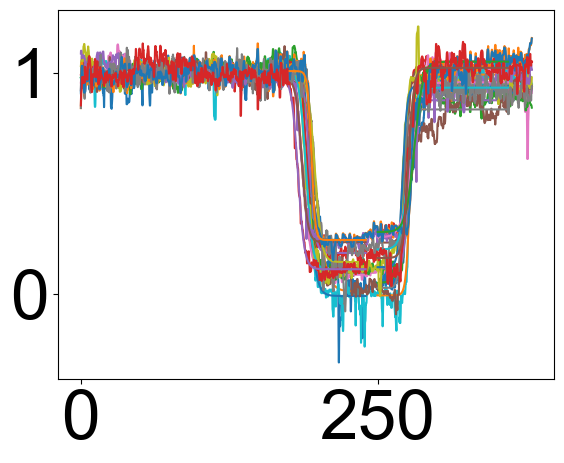

In [65]:
parentDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1'
outputDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1' # Directory where the CSVs of Tau will be saved
os.chdir(parentDir)

sucrose_choice = True
time_mult = 10

# Initialize the list to store time, data, and sucrose concentrations
all_time = []
all_data = []
concentrations = []

tau_values = {}
t0_values = {}
A_values = {}
tau_inc_values = {}


# Walk through all directories and subdirectories in parentDir

for concentration in [200,300,400,500]:
    basedir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/Sophia-Jinming-MB-data/Sophia + Jinming/data/' + str(concentration) + 'mM/cells/'

    # If the directory contains CSV files, process them
    if True:
        tau_values[str(concentration)] = []
        t0_values[str(concentration)] = []
        A_values[str(concentration)] = [] 
        tau_inc_values[str(concentration)] = []  

        if concentration==200:
            allcells = np.zeros((len(os.listdir(basedir))-2, 380*time_mult))  
        else:
            allcells = np.zeros((len(os.listdir(basedir))-1, 380*time_mult))    


        # Loop through the CSV files in this directory
        for cell_number in range(1, len(os.listdir(basedir))):
            if (concentration==200) and (cell_number==4):
                pass
            else:
                #if concentration==200:
                #    print(cell_number)
                individual_cell_mat_data = loadmat('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/Sophia-Jinming-MB-data/Sophia + Jinming/data/' + str(concentration) + 'mM/cells/cell_'+str(cell_number) + '/cell_'+str(cell_number)+'_'+str(concentration)+'_Freq.mat')

                time = individual_cell_mat_data['T'][0]
                data = individual_cell_mat_data['F'][0]

                if data[0] < 0:
                    data = data*-1
                
                # Apply median filtering
                #data = scipy.signal.medfilt(data, kernel_size=601)
                data = signal.medfilt(data, kernel_size=301)

                new_time, interp_data = bin_data(time, data)

                tau_dec, t0_dec, A_dec, tau_inc = calculate_time_constants(new_time, interp_data, str(concentration), sucrose_choice)
                #print(tau_dec), print(t0_dec), print(A_dec)
                if ((tau_dec > 0) & (tau_dec < 40)):
                    tau_values[str(concentration)] += [float(tau_dec)]
                    t0_values[str(concentration)] += [float(t0_dec)]
                    A_values[str(concentration)] += [float(A_dec)]
                    tau_inc_values[str(concentration)] += [float(tau_inc)]
                
                if (concentration==200) and (cell_number>4):
                    allcells[cell_number-2] = interp_data
                else:
                    allcells[cell_number-1] = interp_data


        # Calculate the mean and standard deviation for this folder's data
        data_mean = np.average(allcells, axis=0)
        
        data_mean_norm = data_mean / np.average(data_mean[:180 * time_mult])  # Normalize by the first part of the data  #normally 300 for Luis's data

        data_std = np.std(allcells, axis=0) / np.average(data_mean[:180 * time_mult])  #normally 300 for Luis's data

        # Calculate the upper and lower bounds for the shaded area
        upper = data_mean_norm + 0.5 * data_std
        lower = data_mean_norm - 0.5 * data_std

        # Append time, normalized data, and sucrose concentration
        time = new_time
        all_time.append(time)
        all_data.append(data_mean_norm)

        # Extract sucrose concentration from the directory name
        #sucrose_concentration = os.path.basename(root)[:-2]  # Assuming sucrose concentration is in the last 3 characters
        sucrose_concentration=str(concentration)
        concentrations.append(float(sucrose_concentration))  # Convert to float for sorting

        # Save the data to a CSV file for this sucrose concentration
        sucrose_output_dir = os.path.join(outputDir, f"{sucrose_concentration}mM")
        #os.makedirs(sucrose_output_dir, exist_ok=True)  # Create directory if it doesn't exist

        # Save time and normalized data to CSV
        df_output = pd.DataFrame({
            'Time': time,
            'Normalized Data': data_mean_norm
        })
        output_file = os.path.join(sucrose_output_dir, f"normalized_data_{sucrose_concentration}mM.csv")
        #df_output.to_csv(output_file, index=False)

# Sort the concentrations and associated data
sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]

In [66]:

sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]

print("Sorted concentrations:", sorted_concentrations)

Sorted concentrations: [200.0, 300.0, 400.0, 500.0]


In [67]:
def equalize_lists(data):
    if not data:
        return {}

    lengths = [len(v) for v in data.values()]
    if max(lengths) == 0:
        return {k: [] for k in data}

    max_length = max(lengths)
    return {
        k: v + [np.nan] * (max_length - len(v))
        for k, v in data.items()
    }

In [68]:
print(tau_values)
print(tau_inc_values)
print(t0_values)
print(A_values)

new_tau_values = equalize_lists(tau_values)
new_tau_inc_values = equalize_lists(tau_inc_values)
new_t0_values = equalize_lists(t0_values)
new_A_values = equalize_lists(A_values)

saving_choice = True
if saving_choice:
    pd.DataFrame(new_tau_values).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_tau_values.csv")
    pd.DataFrame(new_tau_inc_values).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_tau_inc_values.csv")
    pd.DataFrame(new_t0_values).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_t0_values.csv")
    pd.DataFrame(new_A_values).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_A_values.csv")

{'200': [1.7663993665134066, 1.313102916889682, 3.8626020356114608, 4.026402973824025, 3.5166099112705393, 4.6974740528068795, 4.45152128137238], '300': [3.66905790299517, 4.578259127184104, 5.4020818849610155, 4.431264142381497, 4.397762847893635, 3.758112872572629, 4.934853713199789, 2.6171966847156805, 3.3887620262251197, 3.8263762060961106], '400': [3.608183251487688, 3.3850063182474064, 5.374938981430557, 3.781778201932983, 4.6739941308508435, 4.821783562272025, 3.958617327067958, 3.65489426138219], '500': [4.6131172659581, 2.3895833734667, 2.383345326445807, 3.1769680051340083, 2.808676475730109, 3.308377652905264, 2.8137426685771936, 1.5441300647381808, 2.4760974863943703, 2.854414968809597, 1.5831329752463517, 2.6914466362918126]}
{'200': [3.8865486408838703, 4.767553334000355, 2.341923034842149, 2.993614792055861, 3.615035031228109, 2.6760301678171086, 2.061158047874047], '300': [1.8775438317815083, 1.8535421372647896, 3.3999162400449547, 2.4607073165771527, 2.6211110088112073

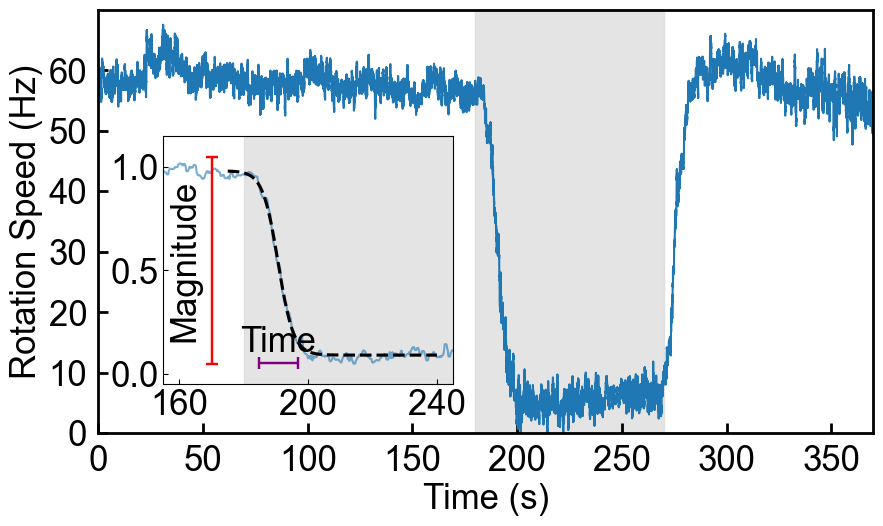

In [69]:
#panel of figure 1
#plot example exponential decay fitting
# Plotting the sorted data
fig, ax = plt.subplots(figsize=(10, 5.5))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({'font.size': 25})

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

individual_cell_mat_data = loadmat('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/Sophia-Jinming-MB-data/Sophia + Jinming/data/500mM/cells/cell_3/cell_3_500_Freq.mat')

ax.plot(individual_cell_mat_data['T'][0], individual_cell_mat_data['F'][0] * -1)  # Format concentration to int

# Finalizing the plot

ax.set_xlabel('Time (s)', fontsize=25)
ax.set_ylabel('Rotation Speed (Hz)', fontsize=25)
# Custom ticks
ax.set_xticks(np.arange(0, 381, 50))  # Set x-ticks every 50
ax.set_xlim(0, 370)
ax.set_yticks(np.arange(0, 70, 10))  # Ticks at 0, 10, ..., 50
ax.set_ylim(0, 70)
ax.axvspan(180, 270, color="lightgray", alpha=0.6)

# Create an inset axis

inset_ax = plt.axes([0.19, 0.20, 0.29, 0.45])  # Adjust the position and size of the inset

# Inset plot: Example exponential decay fitting for normalized data
# Load the inset data

time = individual_cell_mat_data['T'][0]
data = individual_cell_mat_data['F'][0]

if data[0] < 0:
    data = data*-1

# Apply median filtering
#data = scipy.signal.medfilt(data, kernel_size=601)
data = signal.medfilt(data, kernel_size=301)

time, individual_averaged_cell_data = bin_data(time, data)

# Process time and normalize data
data_norm_filt = individual_averaged_cell_data / np.average(individual_averaged_cell_data[:1800])  # Normalize

# Plot the normalized data in the inset
inset_ax.plot(time, data_norm_filt, label="Normalized Data", alpha=0.6)

# Filter data for the decrease segment
mask_decrease = (time >= 175) & (time <= 240)
time_decrease = time[mask_decrease]
speed_decrease = data_norm_filt[mask_decrease]

global speed_initial
global speed_final
speed_initial = np.average(data_norm_filt[(time >= 155) & (time <= 175)])
speed_final = np.average(data_norm_filt[(time >= 215) & (time <= 235)])

# Fit the decrease segment
popt_decrease, _ = curve_fit(
    exp_decrease,
    time_decrease,
    speed_decrease,
    p0=[10, 10],
)
tau_dec,  t0_dec = popt_decrease
A_dec, C_dec = speed_initial-speed_final, speed_final

# Plot the fitted data in the inset
# Plot the fitted curve
inset_ax.plot(
    time_decrease[time_decrease > t0_dec],
    exp_decrease(time_decrease[time_decrease > t0_dec], *popt_decrease),
    '--', label="Fit", color='black', linewidth=2.25
)

# Red vertical error bar for "Magnitude"
# Coordinates for the vertical red error bar
x_mag = 170
y_mag_top = 1.05
y_mag_mid = (np.min(data_norm_filt) + y_mag_top) / 2

# Error bar for "Magnitude"
inset_ax.errorbar(
    x=[x_mag], y=[y_mag_mid],
    yerr=[(y_mag_top - np.min(data_norm_filt)) / 2],
    marker='None', linestyle='None', color='blue', ecolor='red',
    capsize=4, elinewidth=1.75, capthick=1.75
)

# Vertical text along the line, placed *slightly to the left* of the red line
inset_ax.text(
    x_mag - 3, y_mag_mid, 'Magnitude',
    ha='right', va='center', rotation=90, fontsize=25
)

# Orange horizontal error bar for "Time"
inset_ax.errorbar(
    x=[t0_dec + 175], y=[0.05], xerr=[6],
    marker='None', linestyle='None', color='blue', ecolor='purple',
    label="time", capsize=4, elinewidth=1.75, capthick=1.75
)
inset_ax.text(t0_dec + 175, 0.07, 'Time', ha='center', va='bottom', fontsize=25)

# Finalize the inset
#inset_ax.set_xlabel('(s)')
#inset_ax.set_ylabel('Speed')
inset_ax.set_xlim(155, 245)
inset_ax.set_ylim(-0.05, 1.15)
#inset_ax.set_xlabel('(s)', labelpad=0.5)
inset_ax.axvspan(180, 270, color="lightgray", alpha=0.6)
inset_ax.tick_params(which='both', direction='in')
inset_ax.set_xticks([160,200,240])
inset_ax.set_yticks([0, 0.5, 1.0])

# Save the figure
plt.savefig("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/individual_cell_fit.pdf", dpi=350)  

# Show the plot
plt.show()

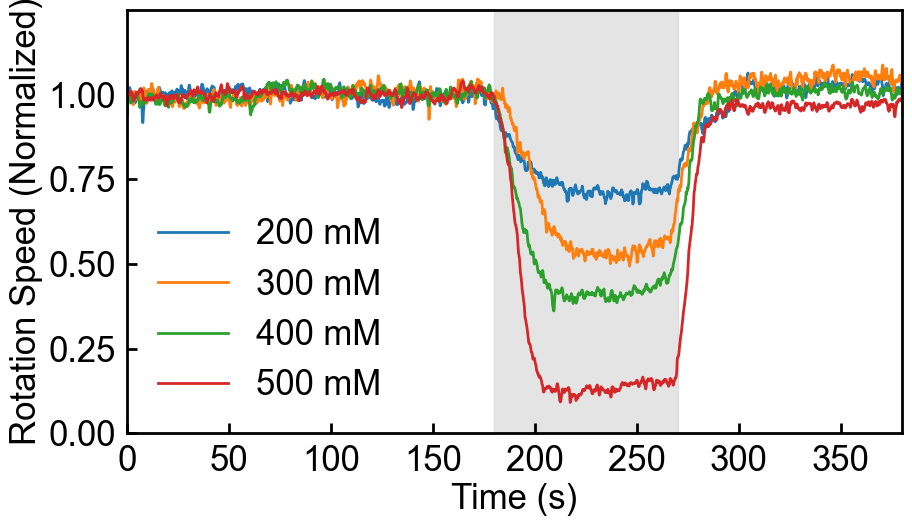

In [70]:
saving_choice = True

fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

# ---- PLOT AND CAPTURE HANDLES ----
lines = []
labels = []

for time, data_norm_filt, conc in zip(sorted_times, sorted_data, sorted_concentrations):

    # defensive shape check
    time = np.asarray(time).squeeze()
    data_norm_filt = np.asarray(data_norm_filt).squeeze()

    n = min(len(time), len(data_norm_filt))
    time = time[:n]
    data_norm_filt = data_norm_filt[:n]

    ln, = ax.plot(time, data_norm_filt, linewidth=2)
    lines.append(ln)
    labels.append(f'{int(conc)} mM')

# Axis labels and limits
ax.set_xlabel('Time (s)', fontsize=25)
ax.set_ylabel('Rotation Speed (Normalized)', fontsize=25)
ax.set_xlim(0, 380)
ax.set_ylim(0, 1.25)

# Custom ticks
ax.set_xticks(np.arange(0, 381, 50))
ticks = np.arange(0, 1.26, 0.25)
ax.set_yticks(ticks[:-1])

# Shaded region
ax.axvspan(180, 270, color="lightgray", alpha=0.6, zorder=0)

# ✅ CORRECT LEGEND
ax.legend(lines, labels, loc='lower left', fontsize=25, frameon=False)

# Save figure
if saving_choice:
    plt.savefig(
        '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/'
        'Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/'
        'Figures/Figure-1/overall_sucrose_trend.pdf',
        dpi=350,
        facecolor='white'
    )

plt.show()

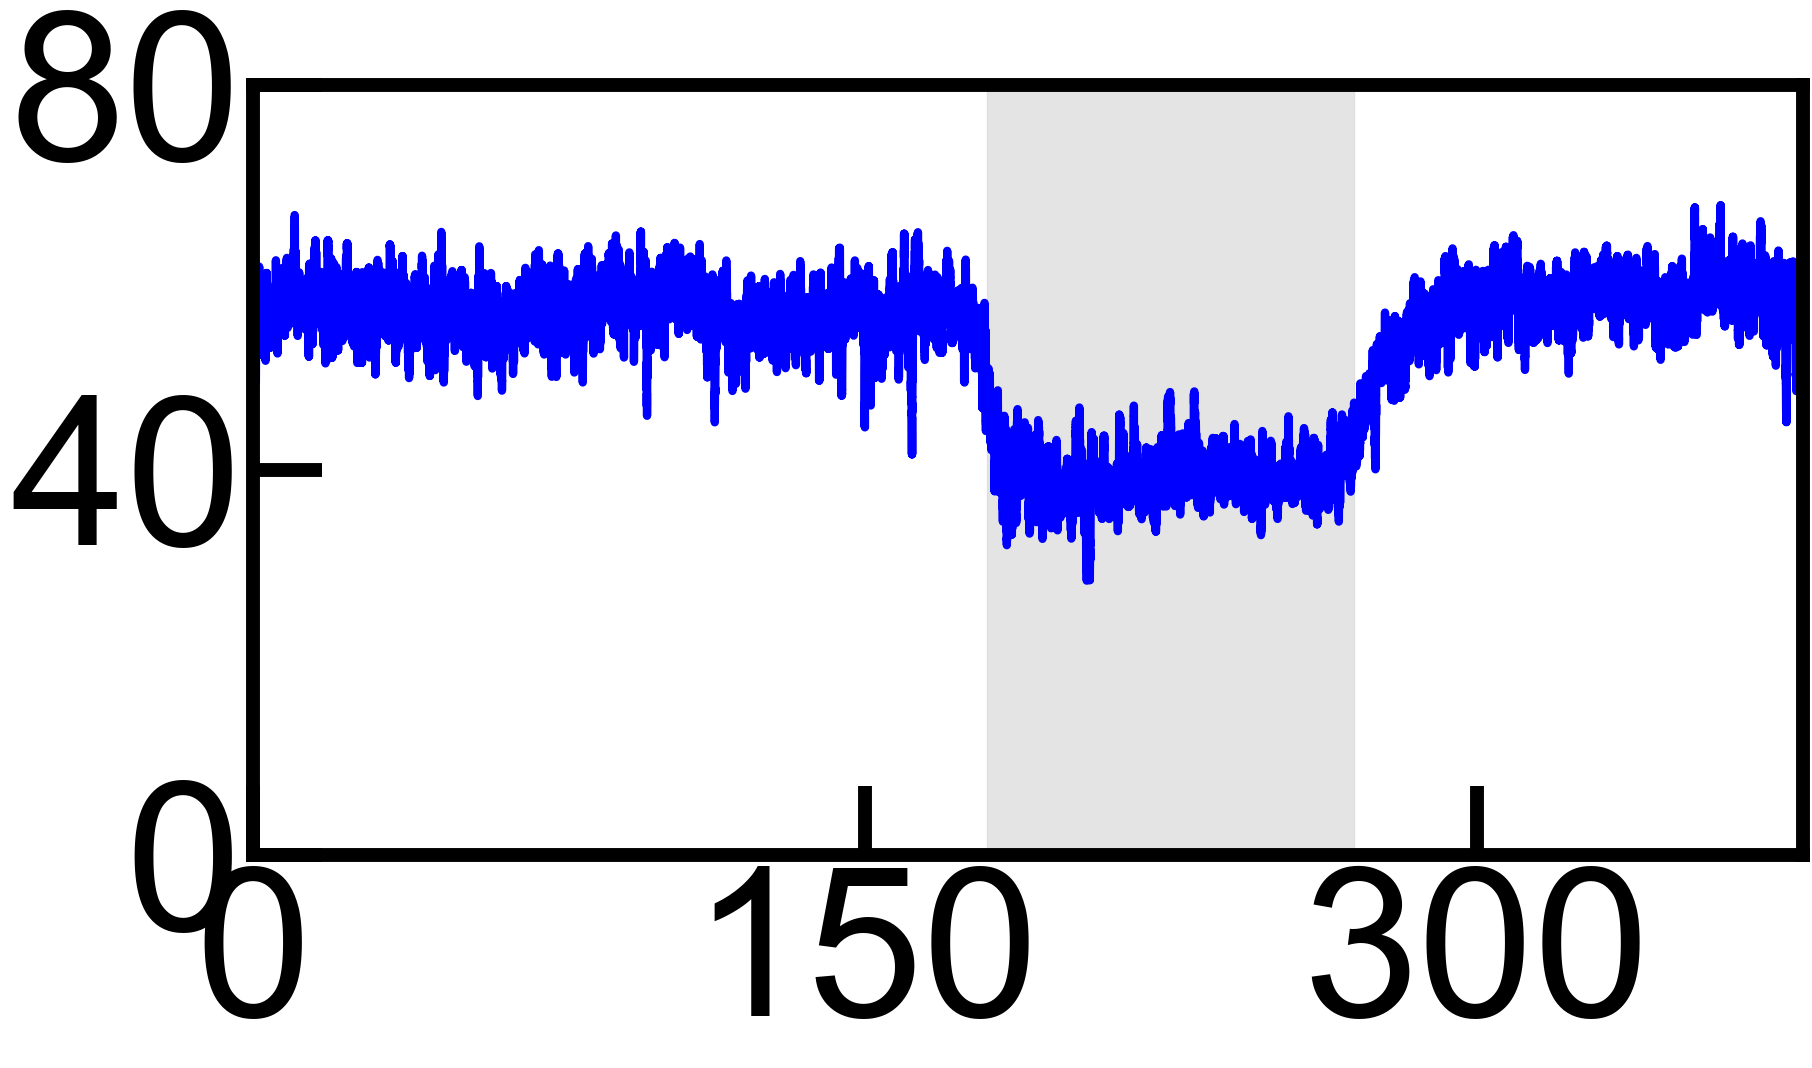

In [71]:
#panel of figure 1
#plot example exponential decay fitting
# Plotting the sorted data
fig, ax = plt.subplots(figsize=(20, 10))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({'font.size': 50})

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(10)

ax.tick_params(axis='x', direction='in', labelsize=150, width=10, length=50, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=150, width=10, length=50, pad=8)

individual_cell_mat_data = loadmat('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/Sophia-Jinming-MB-data/Sophia + Jinming/data/200mM/cells/cell_2/cell_2_200_Freq.mat')

ax.plot(
    individual_cell_mat_data['T'][0], 
    individual_cell_mat_data['F'][0],
    linewidth=6,          # thickness
    color="blue"         # choose color
) # Format concentration to int

# Finalizing the plot

# Custom ticks
ax.set_xticks(np.arange(0, 381, 150))  # Set x-ticks every 50
ax.set_xlim(0, 380)
ax.set_yticks(np.arange(0, 90, 40))  # Ticks at 0, 10, ..., 50
ax.set_ylim(0, 80)
ax.axvspan(180, 270, color="lightgray", alpha=0.6)



# Save the figure
plt.savefig("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/individual_cell_fit_suppl.pdf", dpi=350)  

# Show the plot
plt.show()

In [72]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# -------------------------------
# Global plot settings
# -------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({'font.size': 25})

# -------------------------------
# Paths
# -------------------------------
root_dir = "/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/Sophia-Jinming-MB-data/Sophia + Jinming/data"

save_root = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Supplmental/Sucrose-individual-cells'
os.makedirs(save_root, exist_ok=True)

# -------------------------------
# Loop through concentrations and cells
# -------------------------------
for conc_folder in os.listdir(root_dir):  
    conc_path = os.path.join(root_dir, conc_folder, "cells")
    if not os.path.isdir(conc_path):
        continue  

    for cell_folder in os.listdir(conc_path):  
        cell_path = os.path.join(conc_path, cell_folder)
        if not os.path.isdir(cell_path):
            continue  

        # -------------------------------
        # Create a new figure for this cell
        # -------------------------------
        fig, ax = plt.subplots(figsize=(20, 10))

        # Spine formatting
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(10)

        # Tick formatting
        ax.tick_params(axis='x', direction='in', labelsize=150, width=10, length=50, pad=8)
        ax.tick_params(axis='y', direction='in', labelsize=150, width=10, length=50, pad=8)

        # -------------------------------
        # Load and plot all .mat files for this cell
        # -------------------------------
        plotted = False
        for file in os.listdir(cell_path):
            if file.endswith(".mat") and "Freq" in file:
                mat_path = os.path.join(cell_path, file)
                print(f"Loading: {mat_path}")

                mat_data = loadmat(mat_path)

                ax.plot(mat_data['T'][0], mat_data['F'][0] * -1, linewidth=6, color="blue")  # Format concentration to int
                plotted = True

        # Skip saving if no Freq.mat files were found
        if not plotted:
            plt.close(fig)
            continue

        # -------------------------------
        # Formatting
        # -------------------------------
        # Custom ticks
        ax.set_xticks(np.arange(0, 381, 150))  # Set x-ticks every 50
        ax.set_xlim(0, 380)
        ax.set_yticks(np.arange(0, 90, 40))  # Ticks at 0, 10, ..., 50
        ax.set_ylim(0, 80)
        ax.axvspan(180, 270, color="lightgray", alpha=0.6)
        
        # # Custom ticks (defined but hidden)
        # ax.set_xticks(np.arange(0, 381, 150))
        # ax.tick_params(axis='x', which='both', length=0, labelbottom=False)

        # ax.set_yticks(np.arange(0, 90, 40))
        # ax.tick_params(axis='y', which='both', length=0, labelleft=False)


        # -------------------------------
        # Save figure with unique name
        # -------------------------------
        save_path = os.path.join(save_root, f"{conc_folder}_{cell_folder}.pdf")
        plt.savefig(save_path, dpi=350)
        plt.close(fig)  # free memory
        print(f"Saved figure: {save_path}")

Loading: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/Sophia-Jinming-MB-data/Sophia + Jinming/data/500mM/cells/cell_12/cell_12_500_Freq.mat
Saved figure: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Supplmental/Sucrose-individual-cells/500mM_cell_12.pdf
Loading: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/Sophia-Jinming-MB-data/Sophia + Jinming/data/500mM/cells/cell_1/cell_1_500_Freq.mat
Saved figure: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Supplmental/Sucrose-individual-cells/500mM_cell_1.pdf
Loading: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/B

Data type: <class 'pandas.core.frame.DataFrame'>
Columns: Index(['Unnamed: 0', '200', '300', '400', '500'], dtype='object')
Available columns: Index(['concentration mm', 'read1', 'read2', 'avg_osmolarity',
       'change_in_osmolarity'],
      dtype='object')
Change in Osmolarity: [225.  379.5 560.5 756.5]
Saved summary to: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_tau_summary_by_concentration.csv


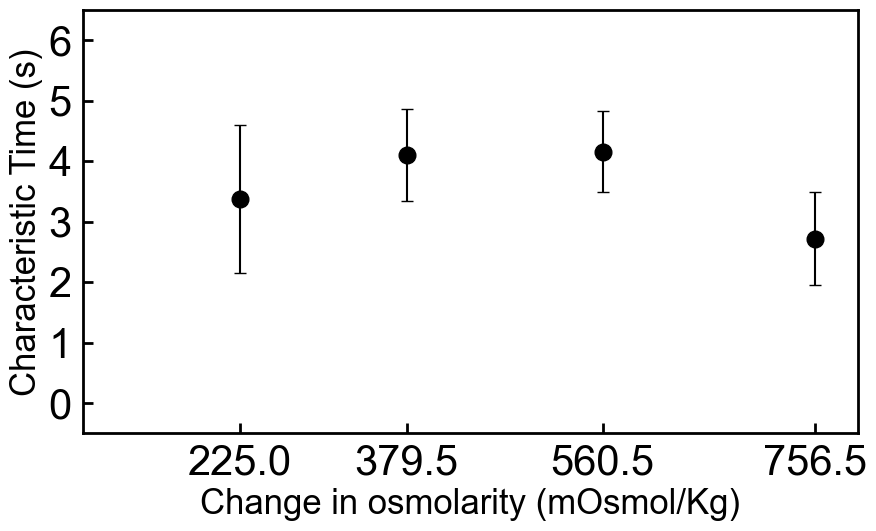

Saved plot to: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_tau.pdf


In [73]:

# --------------------------------------------------
# SET PATHS
# --------------------------------------------------

parentDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1'
os.chdir(parentDir)

file = os.path.join(parentDir, 'sucrose_tau_values.csv')

excel_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sucrose-old.xlsx'

concentrations = [200, 300, 400, 500]

# --------------------------------------------------
# LOAD TAU DATA (IMPORTANT: DO THIS EARLY)
# --------------------------------------------------

data = pd.read_csv(file)
print("Data type:", type(data))
print("Columns:", data.columns)

# --------------------------------------------------
# LOAD + PROCESS OSMOLARITY DATA
# --------------------------------------------------

df_osmo = pd.read_excel(excel_path)

df_osmo.columns = df_osmo.columns.str.strip().str.lower()
print("Available columns:", df_osmo.columns)

read_cols = [col for col in df_osmo.columns if 'read' in col]

if len(read_cols) < 2:
    raise ValueError("Could not find two 'Read' columns.")

df_osmo['avg_osmolarity'] = df_osmo[read_cols[:2]].mean(axis=1)
df_osmo['change_in_osmolarity'] = df_osmo['avg_osmolarity'] - df_osmo['avg_osmolarity'].iloc[0]

# Save updated file
df_osmo.to_excel(excel_path, index=False)

osmotic_shock_values = df_osmo['change_in_osmolarity'].iloc[1:].values
print("Change in Osmolarity:", osmotic_shock_values)

# --------------------------------------------------
# CALCULATE MEAN ± STD PER CONDITION
# --------------------------------------------------

means = []
stds = []
conditions_used = []
delta_osmo_used = []

for column in data.columns:
    if column != "Unnamed: 0":

        tau_values = pd.to_numeric(data[column], errors='coerce').dropna()

        mean_tau = np.mean(tau_values)
        std_tau = np.std(tau_values)

        conc = int(column)
        idx = concentrations.index(conc)
        delta_osmo = osmotic_shock_values[idx]

        means.append(mean_tau)
        stds.append(std_tau)
        conditions_used.append(conc)
        delta_osmo_used.append(delta_osmo)

# --------------------------------------------------
# SAVE SUMMARY CSV
# --------------------------------------------------

summary_df = pd.DataFrame({
    "Concentration_mM": conditions_used,
    "Delta_Osmolarity_mOsm": delta_osmo_used,
    "Mean_tau_s": means,
    "Std_tau_s": stds,
    "N_traces": [
        len(pd.to_numeric(data[str(c)], errors='coerce').dropna())
        for c in conditions_used
    ]
})

summary_path = os.path.join(parentDir, "sucrose_tau_summary_by_concentration.csv")
summary_df.to_csv(summary_path, index=False)

print("Saved summary to:", summary_path)

# --------------------------------------------------
# PLOTTING
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 30})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=30, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=30, width=2, length=7.5, pad=8)

# Plot mean ± std
ax.errorbar(
    osmotic_shock_values,
    means,
    yerr=stds,
    marker="o",
    markeredgecolor='k',
    markersize=12,
    linestyle='None',
    color='black',
    ecolor='black',
    capsize=4
)

ax.set_xticks(osmotic_shock_values)
ax.set_xlabel('Change in osmolarity (mOsmol/Kg)')
ax.set_ylabel('Characteristic Time (s)')
ax.set_xlim(80, 796.5)
ax.set_ylim(-0.5, 6.5)
ax.set_yticks([0, 1, 2, 3, 4, 5, 6])

# Save figure
plot_path = os.path.join(parentDir, 'sucrose_tau.pdf')
plt.savefig(plot_path, dpi=350)
plt.show()

print("Saved plot to:", plot_path)

Data type: <class 'pandas.core.frame.DataFrame'>
Columns: Index(['Unnamed: 0', '200', '300', '400', '500'], dtype='object')
Available columns: Index(['concentration mm', 'read1', 'read2', 'avg_osmolarity',
       'change_in_osmolarity'],
      dtype='object')
Change in Osmolarity: [225.  379.5 560.5 756.5]
Saved summary to: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_tau_inc_summary_by_concentration.csv


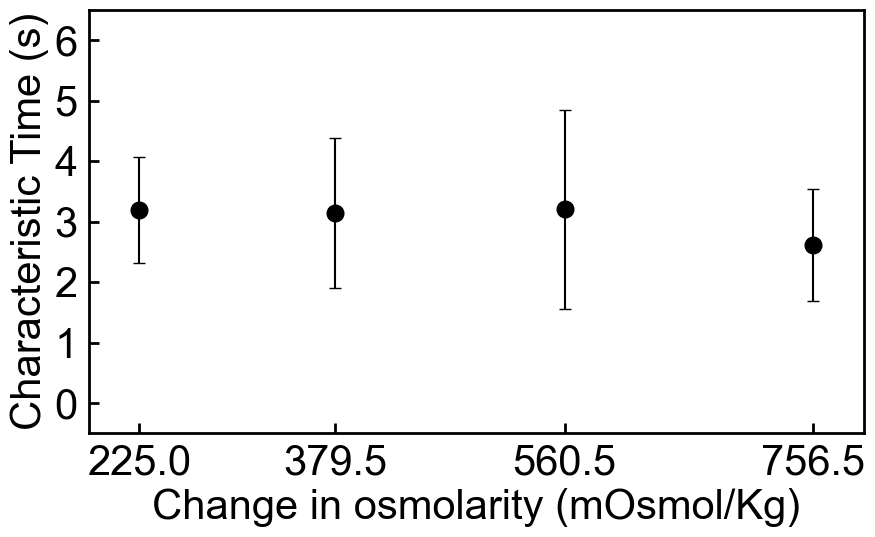

Saved plot to: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_tau_inc.pdf


In [74]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# SET PATHS
# --------------------------------------------------

parentDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1'
os.chdir(parentDir)

file = os.path.join(parentDir, 'sucrose_tau_inc_values.csv')

excel_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sucrose-old.xlsx'

concentrations = [200, 300, 400, 500]

# --------------------------------------------------
# LOAD TAU_inc DATA (FIXED POSITION)
# --------------------------------------------------

data = pd.read_csv(file)
print("Data type:", type(data))
print("Columns:", data.columns)

# --------------------------------------------------
# LOAD + PROCESS OSMOLARITY DATA
# --------------------------------------------------

df_osmo = pd.read_excel(excel_path)

df_osmo.columns = df_osmo.columns.str.strip().str.lower()
print("Available columns:", df_osmo.columns)

read_cols = [col for col in df_osmo.columns if 'read' in col]

if len(read_cols) < 2:
    raise ValueError("Could not find two 'Read' columns.")

df_osmo['avg_osmolarity'] = df_osmo[read_cols[:2]].mean(axis=1)
df_osmo['change_in_osmolarity'] = df_osmo['avg_osmolarity'] - df_osmo['avg_osmolarity'].iloc[0]

# Save updated Excel
df_osmo.to_excel(excel_path, index=False)

osmotic_shock_values = df_osmo['change_in_osmolarity'].iloc[1:].values
print("Change in Osmolarity:", osmotic_shock_values)

# --------------------------------------------------
# CALCULATE τ_inc MEAN ± STD PER CONDITION
# --------------------------------------------------

means = []
stds = []
conditions_used = []
delta_osmo_used = []
n_traces_list = []

for column in data.columns:
    if column != "Unnamed: 0":

        tau_vals = pd.to_numeric(data[column], errors='coerce').dropna()

        mean_tau = np.mean(tau_vals)
        std_tau = np.std(tau_vals)
        n_traces = len(tau_vals)

        conc = int(column)
        idx = concentrations.index(conc)
        delta_osmo = osmotic_shock_values[idx]

        means.append(mean_tau)
        stds.append(std_tau)
        conditions_used.append(conc)
        delta_osmo_used.append(delta_osmo)
        n_traces_list.append(n_traces)

# --------------------------------------------------
# SAVE SUMMARY CSV
# --------------------------------------------------

summary_df = pd.DataFrame({
    "Concentration_mM": conditions_used,
    "Delta_Osmolarity_mOsm": delta_osmo_used,
    "Mean_tau_inc_s": means,
    "Std_tau_inc_s": stds,
    "N_traces": n_traces_list
})

summary_path = os.path.join(parentDir, "sucrose_tau_inc_summary_by_concentration.csv")
summary_df.to_csv(summary_path, index=False)

print("Saved summary to:", summary_path)

# --------------------------------------------------
# PLOTTING
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 30})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=30, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=30, width=2, length=7.5, pad=8)

# Plot
ax.errorbar(
    osmotic_shock_values,
    means,
    yerr=stds,
    marker="o",
    markeredgecolor='k',
    markersize=12,
    linestyle='None',
    color='black',
    ecolor='black',
    capsize=4
)

ax.set_xticks(osmotic_shock_values)
ax.set_xlabel('Change in osmolarity (mOsmol/Kg)')
ax.set_ylabel('Characteristic Time (s)')
ax.set_xlim(185, 796.5)
ax.set_ylim(-0.5, 6.5)
ax.set_yticks([0, 1, 2, 3, 4, 5, 6])

# Save plot
plot_path = os.path.join(parentDir, 'sucrose_tau_inc.pdf')
plt.savefig(plot_path, dpi=350)
plt.show()

print("Saved plot to:", plot_path)

Available columns: Index(['concentration mm', 'read1', 'read2', 'avg_osmolarity',
       'change_in_osmolarity'],
      dtype='object')
Change in Osmolarity: [225.  379.5 560.5 756.5]
Speed Decrease fit slope: 0.0011
Speed Decrease fit intercept: 0.0492
Speed Decrease fit R-squared: 0.9802

Difference fit slope: 0.0006
Difference fit intercept: -0.0292
Difference fit R-squared: 0.9035

Viscosity fit slope: 0.0005
Viscosity fit intercept: 0.0784
Viscosity fit R-squared: 0.9911
Stats saved to: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_A_linear_fit_stats.txt


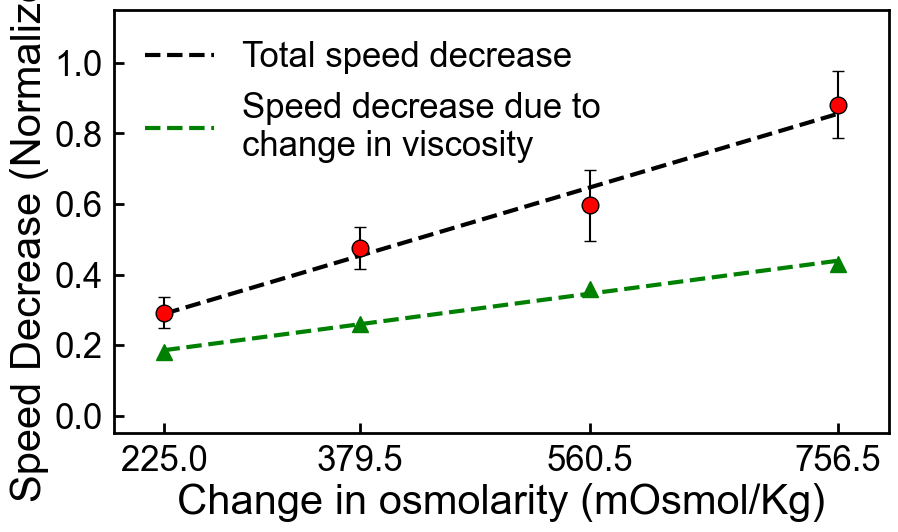

In [75]:


# Plot setup
fig, ax = plt.subplots(figsize=(10, 5.5))
plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

file = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_A_values.csv'

# Load osmolarity data
excel_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sucrose-old.xlsx'
df_osmo = pd.read_excel(excel_path)

df_osmo.columns = df_osmo.columns.str.strip().str.lower()
print("Available columns:", df_osmo.columns)

read_cols = [col for col in df_osmo.columns if 'read' in col]
if len(read_cols) < 2:
    raise ValueError("Could not find two 'Read' columns in the Excel file.")

df_osmo['avg_osmolarity'] = df_osmo[read_cols[:2]].mean(axis=1)
df_osmo['change_in_osmolarity'] = df_osmo['avg_osmolarity'] - df_osmo['avg_osmolarity'].iloc[0]
df_osmo.to_excel(excel_path, index=False)

osmotic_shock_values = df_osmo['change_in_osmolarity'].iloc[1:].values
print("Change in Osmolarity:", osmotic_shock_values)

# Process A values and plot
means = []
stds = []
concentrations = []

if file.endswith(".csv"):
    data = pd.read_csv(file)
    valid_columns = [col for col in data.columns if col != "Unnamed: 0"]

    if len(valid_columns) != len(osmotic_shock_values):
        raise ValueError(f"Mismatch between data columns ({len(valid_columns)}) and osmotic shock values ({len(osmotic_shock_values)}).")

    for i, column in enumerate(valid_columns):
        mean = np.mean(data[column])
        std = np.std(data[column])

        concentrations.append(int(column))
        means.append(mean)
        stds.append(std)

        #ax.scatter([osmotic_shock_values[i]] * len(data[column]), data[column], color='black', alpha=0.2)

    # === First Line: Speed Decrease ===
    ax.errorbar(
        osmotic_shock_values, means, yerr=stds,
        marker="o", markeredgecolor='k', markersize=12,
        linestyle='None', color='red', ecolor='black', capsize=4)
    #     label='Total Speed Decrease'
    # )

    ax.set_xticks(osmotic_shock_values)
    ax.set_xlabel('Change in osmolarity (mOsmol/Kg)')
    ax.set_ylabel('Speed Decrease (Normalized)')
    ax.set_xlim(185, 796.5)
    ax.set_ylim(-0.05, 1.15)

    x_data = np.array(osmotic_shock_values)
    y_data = np.array(means)

    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    x_fit = np.linspace(min(x_data), max(x_data), 1000)
    y_fit = slope * x_fit + intercept

    ax.plot(x_fit, y_fit, linestyle="--", color="black", linewidth=3, label='Total speed decrease')

    # # # === Second Line: Speed Decrease - Viscosity ===
    viscosity_dict = {
        60: 0,
        200: 0.18,
        300: 0.26,
        400: 0.36,
        500: 0.43
    }

    viscosities = [viscosity_dict.get(c, np.nan) for c in concentrations]
    diff_values = np.array(means) - np.array(viscosities)

    # ax.errorbar(
    #     osmotic_shock_values, diff_values, yerr=stds,
    #  marker="s", markeredgecolor='blue', markersize=12,
    #  linestyle='None', color='blue', ecolor='blue', capsize=4,
    #      label='Remaining Speed Decrease'
    # )

    slope_diff, intercept_diff, r_value_diff, p_value_diff, std_err_diff = linregress(x_data, diff_values)
    y_fit_diff = slope_diff * x_fit + intercept_diff

    # ax.plot(x_fit, y_fit_diff, linestyle="--", color="blue", linewidth=3)
    # #     #label=f"Reaming Speed Decrease"
    # # 

    # === Third Line: Viscosity Alone ===
    ax.errorbar(
        osmotic_shock_values, viscosities, yerr=None,
        marker="^", markeredgecolor='green', markersize=12,
        linestyle='None', color='green', ecolor='green', capsize=4)
    #     label='Speeds Decrease due to Viscosity'
    # )

    slope_visc, intercept_visc, r_value_visc, p_value_visc, std_err_visc = linregress(
        x_data, viscosities
    )

    y_fit_visc = slope_visc * x_fit + intercept_visc

    ax.plot(
        x_fit, y_fit_visc,
        linestyle="--", color="green", linewidth=3, label='Speed decrease due to \nchange in viscosity' )

    # Add legend
    ax.legend(loc='upper left', frameon=False)

    # Print stats
    print(f"Speed Decrease fit slope: {slope:.4f}")
    print(f"Speed Decrease fit intercept: {intercept:.4f}")
    print(f"Speed Decrease fit R-squared: {r_value**2:.4f}\n")

    print(f"Difference fit slope: {slope_diff:.4f}")
    print(f"Difference fit intercept: {intercept_diff:.4f}")
    print(f"Difference fit R-squared: {r_value_diff**2:.4f}\n")

    print(f"Viscosity fit slope: {slope_visc:.4f}")
    print(f"Viscosity fit intercept: {intercept_visc:.4f}")
    print(f"Viscosity fit R-squared: {r_value_visc**2:.4f}")

    # Save stats
    stats_output_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_A_linear_fit_stats.txt'
    with open(stats_output_path, 'w') as f:
        f.write("Linear Fit Statistics - Speed Decrease\n")
        f.write("====================\n")
        f.write(f"Slope: {slope:.6f}\n")
        f.write(f"Intercept: {intercept:.6f}\n")
        f.write(f"R-squared: {r_value**2:.6f}\n")
        f.write(f"P-value: {p_value:.6e}\n")
        f.write(f"Standard Error: {std_err:.6f}\n\n")

        f.write("Linear Fit Statistics - Difference (Speed Decrease - Viscosity)\n")
        f.write("====================\n")
        f.write(f"Slope: {slope_diff:.6f}\n")
        f.write(f"Intercept: {intercept_diff:.6f}\n")
        f.write(f"R-squared: {r_value_diff**2:.6f}\n")
        f.write(f"P-value: {p_value_diff:.6e}\n")
        f.write(f"Standard Error: {std_err_diff:.6f}\n\n")

        f.write("Linear Fit Statistics - Viscosity\n")
        f.write("====================\n")
        f.write(f"Slope: {slope_visc:.6f}\n")
        f.write(f"Intercept: {intercept_visc:.6f}\n")
        f.write(f"R-squared: {r_value_visc**2:.6f}\n")
        f.write(f"P-value: {p_value_visc:.6e}\n")
        f.write(f"Standard Error: {std_err_visc:.6f}\n")

    print(f"Stats saved to: {stats_output_path}")

    # Save and show
    plt.savefig('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_A_linear_fit.pdf', dpi=350)
    plt.show()

Available columns: Index(['concentration mm', 'read1', 'read2', 'avg_osmolarity',
       'change_in_osmolarity'],
      dtype='object')
Change in Osmolarity: [225.  379.5 560.5 756.5]
Speed Decrease fit slope: 0.0011
Speed Decrease fit intercept: 0.0492
Speed Decrease fit R-squared: 0.9802

Difference fit slope: 0.0006
Difference fit intercept: -0.0292
Difference fit R-squared: 0.9035
Stats saved to: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_A_linear_fit_stats_remaining_speed.txt


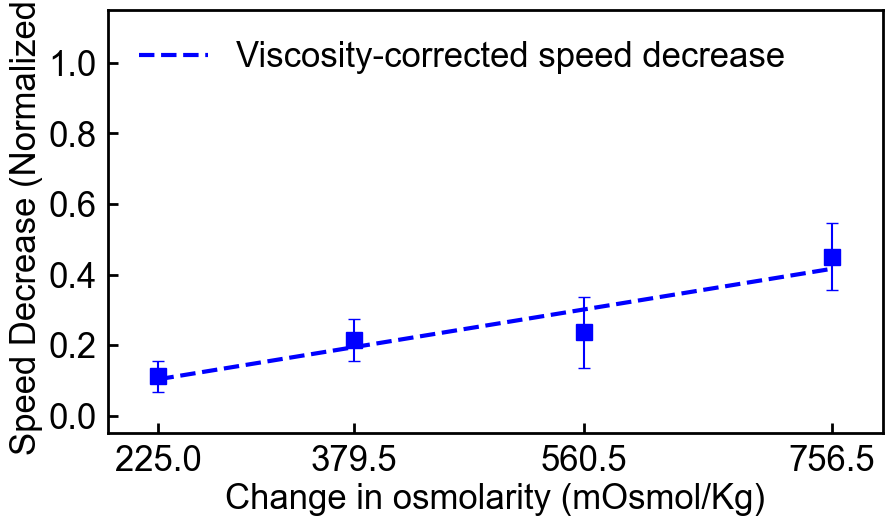

In [76]:


# Plot setup
fig, ax = plt.subplots(figsize=(10, 5.5))
plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

file = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_A_values.csv'

# Load osmolarity data
excel_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sucrose-old.xlsx'
df_osmo = pd.read_excel(excel_path)

df_osmo.columns = df_osmo.columns.str.strip().str.lower()
print("Available columns:", df_osmo.columns)

read_cols = [col for col in df_osmo.columns if 'read' in col]
if len(read_cols) < 2:
    raise ValueError("Could not find two 'Read' columns in the Excel file.")

df_osmo['avg_osmolarity'] = df_osmo[read_cols[:2]].mean(axis=1)
df_osmo['change_in_osmolarity'] = df_osmo['avg_osmolarity'] - df_osmo['avg_osmolarity'].iloc[0]
df_osmo.to_excel(excel_path, index=False)

osmotic_shock_values = df_osmo['change_in_osmolarity'].iloc[1:].values
print("Change in Osmolarity:", osmotic_shock_values)

# Process A values and plot
means = []
stds = []
concentrations = []

if file.endswith(".csv"):
    data = pd.read_csv(file)
    valid_columns = [col for col in data.columns if col != "Unnamed: 0"]

    if len(valid_columns) != len(osmotic_shock_values):
        raise ValueError(f"Mismatch between data columns ({len(valid_columns)}) and osmotic shock values ({len(osmotic_shock_values)}).")

    for i, column in enumerate(valid_columns):
        mean = np.mean(data[column])
        std = np.std(data[column])

        concentrations.append(int(column))
        means.append(mean)
        stds.append(std)

        # ax.scatter([osmotic_shock_values[i]] * len(data[column]), data[column], color='black', alpha=0.2)

    # Error bars for Speed Decrease
    # ax.errorbar(
    #     osmotic_shock_values, means, yerr=stds,
    #     marker="o", markeredgecolor='k', markersize=12,
    #     linestyle='None', color='red', ecolor='black', capsize=4,
    #     label='Total Speed Decrease'
    # )

    ax.set_xticks(osmotic_shock_values)
    ax.set_xlabel('Change in osmolarity (mOsmol/Kg)')
    ax.set_ylabel('Speed Decrease (Normalized)')
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlim(185, 796.5)

    # === LINEAR TREND LINE FIT for Speed Decrease ===
    x_data = np.array(osmotic_shock_values)
    y_data = np.array(means)

    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    x_fit = np.linspace(min(x_data), max(x_data), 1000)
    y_fit = slope * x_fit + intercept

    # # Plot trend line for Speed Decrease
    # ax.plot(x_fit, y_fit, linestyle="--", color="black", linewidth=3) # label=f"Speed Decrease fit\n$R^2$ = {r_value**2:.3f}"

    # --- Secondary line: Speed Decrease - Viscosity ---

    # Viscosity values from the provided table (cP)
    viscosity_dict = {
        60: 0,
        200: 0.18,
        300: 0.26,
        400: 0.36,
        500: 0.43
    }

    # Match viscosity values to concentrations
    viscosities = [viscosity_dict.get(c, np.nan) for c in concentrations]

    # Calculate difference
    diff_values = np.array(means) - np.array(viscosities)

    # Plot difference with error bars
    ax.errorbar(
        osmotic_shock_values, diff_values, yerr=stds,
        marker="s", markeredgecolor='blue', markersize=12,
        linestyle='None', color='blue', ecolor='blue', capsize=4)
    #     label='Remaining Speed Decrease'
    # )

    # Linear regression for difference data
    slope_diff, intercept_diff, r_value_diff, p_value_diff, std_err_diff = linregress(x_data, diff_values)
    y_fit_diff = slope_diff * x_fit + intercept_diff

    # Plot linear fit for difference data
    ax.plot(
        x_fit, y_fit_diff,
        linestyle="--", color="blue", linewidth=3,
        label='Viscosity-corrected speed decrease')
    

    # Add legend
    ax.legend(loc='upper left', frameon=False)

    # Print stats for both fits
    print(f"Speed Decrease fit slope: {slope:.4f}")
    print(f"Speed Decrease fit intercept: {intercept:.4f}")
    print(f"Speed Decrease fit R-squared: {r_value**2:.4f}\n")

    print(f"Difference fit slope: {slope_diff:.4f}")
    print(f"Difference fit intercept: {intercept_diff:.4f}")
    print(f"Difference fit R-squared: {r_value_diff**2:.4f}")

    # Save stats for Speed Decrease fit
    stats_output_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_A_linear_fit_stats_remaining_speed.txt'
    with open(stats_output_path, 'w') as f:
        f.write("Linear Fit Statistics - Speed Decrease\n")
        f.write("====================\n")
        f.write(f"Slope: {slope:.6f}\n")
        f.write(f"Intercept: {intercept:.6f}\n")
        f.write(f"R-squared: {r_value**2:.6f}\n")
        f.write(f"P-value: {p_value:.6e}\n")
        f.write(f"Standard Error: {std_err:.6f}\n\n")

        f.write("Linear Fit Statistics - Difference (Speed Decrease - Viscosity)\n")
        f.write("====================\n")
        f.write(f"Slope: {slope_diff:.6f}\n")
        f.write(f"Intercept: {intercept_diff:.6f}\n")
        f.write(f"R-squared: {r_value_diff**2:.6f}\n")
        f.write(f"P-value: {p_value_diff:.6e}\n")
        f.write(f"Standard Error: {std_err_diff:.6f}\n")

    print(f"Stats saved to: {stats_output_path}")

    # Save and show plot
    plt.savefig('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1/sucrose_A_linear_fit_remaining_speed.pdf', dpi=350)
    plt.show()

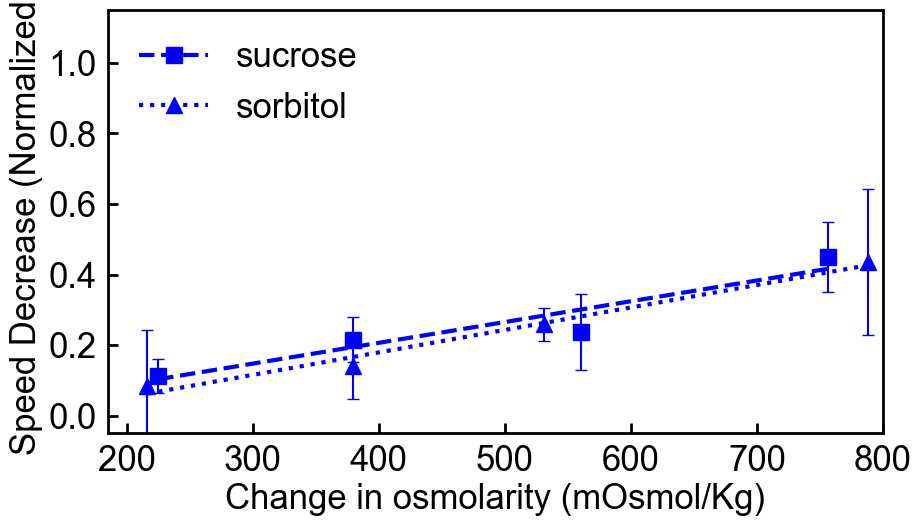

In [77]:

plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(10, 5.5))
for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_linewidth(2)

ax.tick_params(axis='x', direction='in', width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', width=2, length=7.5, pad=8)

# --- Sucrose Section ---
sucrose_dir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Figure-1'
sucrose_file = os.path.join(sucrose_dir, "sucrose_A_values.csv")
sucrose_excel = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sucrose-old.xlsx'

df_sucrose_osmo = pd.read_excel(sucrose_excel)
df_sucrose_osmo.columns = df_sucrose_osmo.columns.str.strip().str.lower()
read_cols = [col for col in df_sucrose_osmo.columns if 'read' in col]
df_sucrose_osmo['avg_osmolarity'] = df_sucrose_osmo[read_cols[:2]].mean(axis=1)
df_sucrose_osmo['change_in_osmolarity'] = df_sucrose_osmo['avg_osmolarity'] - df_sucrose_osmo['avg_osmolarity'].iloc[0]
sucrose_osmo = df_sucrose_osmo['change_in_osmolarity'].iloc[1:].values

df_sucrose = pd.read_csv(sucrose_file)
columns = [col for col in df_sucrose.columns if col != "Unnamed: 0"]
sucrose_concs = [int(col) for col in columns]
sucrose_means = [df_sucrose[col].mean() for col in columns]
sucrose_stds = [df_sucrose[col].std() for col in columns]

sucrose_viscosity = {
    60: 0,
    200: 0.18,
    300: 0.26,
    400: 0.36,
    500: 0.43
}
sucrose_visc_vals = [sucrose_viscosity.get(c, np.nan) for c in sucrose_concs]
sucrose_diff = np.array(sucrose_means) - np.array(sucrose_visc_vals)

ax.errorbar(
    sucrose_osmo, sucrose_diff, yerr=sucrose_stds,
    marker="s", markersize=12, linestyle='None',
    color='blue', ecolor='blue', capsize=4
)

slope_suc, intercept_suc, r_suc, p_suc, err_suc = linregress(sucrose_osmo, sucrose_diff)
x_fit = np.linspace(min(sucrose_osmo), max(sucrose_osmo), 1000)
ax.plot(x_fit, slope_suc * x_fit + intercept_suc, linestyle="--", color="blue", linewidth=3)

# --- Sorbitol Section ---
sorbitol_dir = "/Users/luismeneses/Desktop/Sorbitol"
sorbitol_file = os.path.join(sorbitol_dir, "sucrose_A_values.csv")
sorbitol_excel = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sorbitol.xlsx'

df_sorbitol_osmo = pd.read_excel(sorbitol_excel)
df_sorbitol_osmo.columns = df_sorbitol_osmo.columns.str.strip().str.lower()
read_cols = [col for col in df_sorbitol_osmo.columns if 'read' in col]
df_sorbitol_osmo['avg_osmolarity'] = df_sorbitol_osmo[read_cols[:2]].mean(axis=1)
df_sorbitol_osmo['change_in_osmolarity'] = df_sorbitol_osmo['avg_osmolarity'] - df_sorbitol_osmo['avg_osmolarity'].iloc[0]
sorbitol_osmo = df_sorbitol_osmo['change_in_osmolarity'].iloc[1:].values

df_sorbitol = pd.read_csv(sorbitol_file)
valid_columns = [col for col in df_sorbitol.columns if col != "Unnamed: 0"]
cleaned_columns = []
for col in valid_columns:
    match = re.search(r'(\d+)', col)
    if match:
        cleaned_columns.append((int(match.group()), col))

cleaned_columns.sort()
sorbitol_concs = [x[0] for x in cleaned_columns]
sorbitol_means = [df_sorbitol[x[1]].mean() for x in cleaned_columns]
sorbitol_stds = [df_sorbitol[x[1]].std() for x in cleaned_columns]

sorbitol_viscosity = {
    200: 0.14,
    300: 0.20,
    400: 0.26,
    500: 0.32
}
sorbitol_visc_vals = [sorbitol_viscosity.get(c, np.nan) for c in sorbitol_concs]
sorbitol_diff = np.array(sorbitol_means) - np.array(sorbitol_visc_vals)

ax.errorbar(
    sorbitol_osmo, sorbitol_diff, yerr=sorbitol_stds,
    marker="^", markersize=12, linestyle='None',
    color='blue', ecolor='blue', capsize=4
)

slope_sor, intercept_sor, r_sor, p_sor, err_sor = linregress(sorbitol_osmo, sorbitol_diff)
x_fit_sor = np.linspace(min(sorbitol_osmo), max(sorbitol_osmo), 1000)
ax.plot(x_fit_sor, slope_sor * x_fit_sor + intercept_sor, linestyle=":", color="blue", linewidth=3)

# --- Final Plot Styling ---
ax.set_xlabel('Change in osmolarity (mOsmol/Kg)')
ax.set_ylabel('Speed Decrease (Normalized)')
ax.set_ylim(-0.05, 1.15)
ax.set_xlim(185, 800)
ax.set_yticks(np.arange(0.0, 1.2, 0.2))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))

# Custom legend (marker on top of line style)
custom_handles = [
    Line2D([0], [0], color='blue', marker='s', markersize=12,
           linestyle='--', linewidth=3, label='sucrose',
           markerfacecolor='blue', markeredgecolor='blue'),
    Line2D([0], [0], color='blue', marker='^', markersize=12,
           linestyle=':', linewidth=3, label='sorbitol',
           markerfacecolor='blue', markeredgecolor='blue')
]

ax.legend(handles=custom_handles, loc='upper left', frameon=False)

# Save combined figure
output_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Figures/Supplmental/Viscosity-of-sucrose-sorb/combined_remaining_speed_decrease.pdf'
plt.savefig(output_path, dpi=350)
plt.show()